# Part 1d. Baseline Implementation

In [1]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [2]:
# Load the dataset

df = pd.read_csv("hf://datasets/processvenue/SARCASM_VS_NON_SARCASM/PROJ_SARCASM_VS_NON_SARCASM_6000_0004(HF).csv", index_col='S.No')

/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The dataset that we use for this project, the sarcasm vs no-sarcasm dataset, doesn't have a proper ground truth label, rather, it contains the annotations made by two human annotators. The inter-annotator agreement is 63.92%, which illustrates the difficulty of the task at hand, namely, identifying sarcasm. This complexity comes from the fact that the identification of sarcasm involves a proper understanding of the context and nuance that often escape to many machine learning models.

In order to train the model using labelled data, we drop all the observations where the annotators disagreed, and proceed on the remaining corpus.

In [3]:
# Generate the labels from the annotators agreement

df['label'] = (df['Annotator 1']==df['Annotator 2'])
df['label'] = np.where(df['label'], df['Annotator 1'], 'Unknown')
#df.to_csv('../data/sarcasm_labelled.csv')

iaa = len(df[df['label']!='Unknown']) / len(df)
print(f"Inter-Annotator Agreement: {round(iaa, 4)*100}%")

df = df[df['label']!='Unknown']

df

Inter-Annotator Agreement: 63.92%


,Sentence,Annotator 1,Annotator 2,IAA,label
S.No,,,,,
1,with such eloquent and compelling arguments as...,Sarcastic,Sarcastic,Agree,Sarcastic
2,"fantasy,fairy tale, wild imagination, adsurd ,...",Non-Sarcastic,Non-Sarcastic,Agree,Non-Sarcastic
3,"'if carrying guns became legal, then police co...",Sarcastic,Sarcastic,Agree,Sarcastic
5,Poor little poopie. \r\nIf your gay sex agenda...,Sarcastic,Sarcastic,Agree,Sarcastic
6,":p I wish! If I did, I'd be as wealthy as the ...",Sarcastic,Sarcastic,Agree,Sarcastic
...,...,...,...,...,...
5994,"Nice try twisting my words, Simone. My post ab...",Sarcastic,Sarcastic,Agree,Sarcastic
5996,"Quit using movie stars. After Kerry lost, a lo...",Sarcastic,Sarcastic,Agree,Sarcastic
5997,Hoooahhhh! The smartest man in the world lives...,Sarcastic,Sarcastic,Agree,Sarcastic


We design up to 4 approaches to tackle this classification problem using rule-based classifiers. All of them, however, start by splitting the sentences in logical units that express the same sentiment, using the comma (",") as the separator. This idea comes from the intuition that one of the most present forms of sarcasm consists in expressing a positive sentiment followed by something that clearly denotes a negative sentiment (such as "I love this, nothing like being stuck in traffic every day!"), or the other way around. Therefore, each sentence is split in smaller units.

In [4]:
# Split by commas to get separate sentence structures

df['splits'] = df['Sentence'].str.split(',')
df['nb_splits'] = df['splits'].str.len()
df

,Sentence,Annotator 1,Annotator 2,IAA,label,splits,nb_splits
S.No,,,,,,,
1,with such eloquent and compelling arguments as...,Sarcastic,Sarcastic,Agree,Sarcastic,[with such eloquent and compelling arguments a...,1
2,"fantasy,fairy tale, wild imagination, adsurd ,...",Non-Sarcastic,Non-Sarcastic,Agree,Non-Sarcastic,"[fantasy, fairy tale, wild imagination, adsu...",9
3,"'if carrying guns became legal, then police co...",Sarcastic,Sarcastic,Agree,Sarcastic,"['if carrying guns became legal, then police ...",3
5,Poor little poopie. \r\nIf your gay sex agenda...,Sarcastic,Sarcastic,Agree,Sarcastic,[Poor little poopie. \r\nIf your gay sex agend...,1
6,":p I wish! If I did, I'd be as wealthy as the ...",Sarcastic,Sarcastic,Agree,Sarcastic,"[:p I wish! If I did, I'd be as wealthy as th...",3
...,...,...,...,...,...,...,...
5994,"Nice try twisting my words, Simone. My post ab...",Sarcastic,Sarcastic,Agree,Sarcastic,"[Nice try twisting my words, Simone. My post ...",5
5996,"Quit using movie stars. After Kerry lost, a lo...",Sarcastic,Sarcastic,Agree,Sarcastic,"[Quit using movie stars. After Kerry lost, a ...",3
5997,Hoooahhhh! The smartest man in the world lives...,Sarcastic,Sarcastic,Agree,Sarcastic,[Hoooahhhh! The smartest man in the world live...,1


Maximum number of splits within a sentence: 35


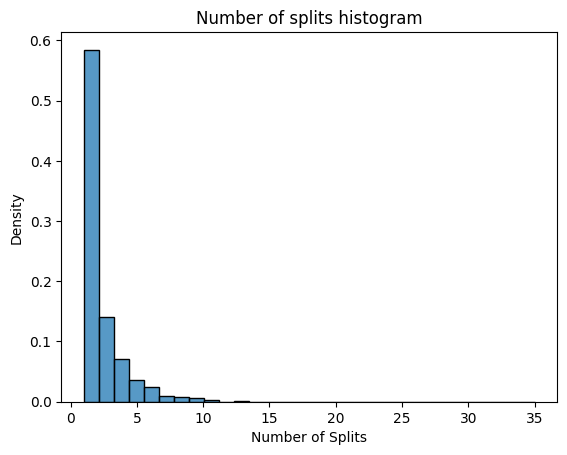

In [5]:
# Basic splits statistics and histogram

max_splits = max(df['nb_splits'])

print(F"Maximum number of splits within a sentence: {max_splits}")

sns.histplot(df['nb_splits'], bins=30, stat='density')
plt.title('Number of splits histogram')
plt.xlabel('Number of Splits')
plt.show()

#### APPROACH 1. Look-ahead for opposing sentiment

The first approach that we implement corresponds to getting a valence score for each split within a sentence, and then, and for each split, checking whether the split right after it has a different sign, which would indicate that there are two contrasting positive/negative phrases. We use VADER to get a valence score for each split.

In [6]:
# First approach: look-ahead for opposing sentiment

analyzer = SentimentIntensityAnalyzer()

# Helper function to get a valence score for each
# split within a sentence

def get_split_score(split_list, index):
    if isinstance(split_list, list) and len(split_list) > index:
        text = split_list[index]
        if pd.notna(text) and text != "":
            return analyzer.polarity_scores(text)['compound']
    return 0.0

# We build as many new columns as the maximum number 
# of splits, and compute the valence for each one of 
# them. For all the cases where the number of splits
# is less than the maximum across the corpus, we
# default to 0 as the valence
 
for s in range(max_splits):
    df[f'score_{s+1}'] = df['splits'].apply(lambda x: get_split_score(x, index=s))

# Look-ahead logic. We shift and then compare signs

score_cols = [f'score_{i+1}' for i in range(35)]
signs_matrix = np.sign(df[score_cols])
next_signs_matrix = signs_matrix.shift(-1, axis=1)
sign_flips = (signs_matrix * next_signs_matrix) < 0
df['pred_sarcasm_v1'] = sign_flips.any(axis=1)
df['pred_sarcasm_v1'] = np.where(df['pred_sarcasm_v1'], 'Sarcastic', 'Non-Sarcastic')

df.head(5)

,Sentence,Annotator 1,Annotator 2,IAA,label,splits,nb_splits,score_1,score_2,score_3,...,score_27,score_28,score_29,score_30,score_31,score_32,score_33,score_34,score_35,pred_sarcasm_v1
S.No,,,,,,,,,,,,,,,,,,,,,
1,with such eloquent and compelling arguments as...,Sarcastic,Sarcastic,Agree,Sarcastic,[with such eloquent and compelling arguments a...,1,0.0258,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Non-Sarcastic
2,"fantasy,fairy tale, wild imagination, adsurd ,...",Non-Sarcastic,Non-Sarcastic,Agree,Non-Sarcastic,"[fantasy, fairy tale, wild imagination, adsu...",9,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sarcastic
3,"'if carrying guns became legal, then police co...",Sarcastic,Sarcastic,Agree,Sarcastic,"['if carrying guns became legal, then police ...",3,0.1280,-0.1421,0.4215,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sarcastic
5,Poor little poopie. \r\nIf your gay sex agenda...,Sarcastic,Sarcastic,Agree,Sarcastic,[Poor little poopie. \r\nIf your gay sex agend...,1,0.5132,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Non-Sarcastic
6,":p I wish! If I did, I'd be as wealthy as the ...",Sarcastic,Sarcastic,Agree,Sarcastic,"[:p I wish! If I did, I'd be as wealthy as th...",3,0.6114,0.3612,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Non-Sarcastic


               precision    recall  f1-score   support

Non-Sarcastic       0.36      0.81      0.50      1406
    Sarcastic       0.58      0.16      0.25      2391

     accuracy                           0.40      3797
    macro avg       0.47      0.48      0.37      3797
 weighted avg       0.50      0.40      0.34      3797



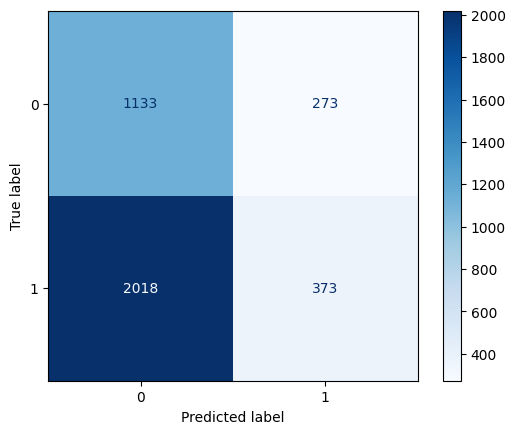

In [7]:
# Performance evaluation

print(classification_report(df['label'], df['pred_sarcasm_v1']))
cm = confusion_matrix(df['label'], df['pred_sarcasm_v1'])
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')

As the results above displays, not only is the performance of our first rule-based model bad, but it is worse than random. Note that by leveraging the class imbalance in the dataset we could reach a 62.97% accuracy by always predicting "Sarcasm", but then the model would not be learning anything. The recall, which corresponds to the True Positive Rate, for the "Non-Sarcastic" class performs good, but at the expense of a 36% precision for the class. For the case of the "Sarcastic" category, precision is increased up to 58%, not because the number of true positives is large, but because the number of false positives happens to be even smaller due to the aforementioned class imbalance.

#### APPROACH 2. Look at the strongest splits within a sentence

To try to overcome the bad performance of the first approach, in the second rule-based model that we propose we turn away from strictly looking ahead for an opposing valence, and instead we retrieve the maximum and minimum values from the VADER valence scores. Building on top of the reasoning that we presented previously, the logic behind this new approach is that sarcastic sentences often have at least two parts with a strong, opposed sentiment. Therefore, in case that a split with a strong positive valence and a split with a strong negative are present within a sentence, sarcasm is flagged.

To define what constitutes a strong positive/negative valence, we refer to the VADER documentation, which defines a compound score of $|0.5|$ or more as an indicator of a positive/negative text.

               precision    recall  f1-score   support

Non-Sarcastic       0.36      0.78      0.49      1406
    Sarcastic       0.58      0.18      0.27      2391

     accuracy                           0.40      3797
    macro avg       0.47      0.48      0.38      3797
 weighted avg       0.50      0.40      0.35      3797



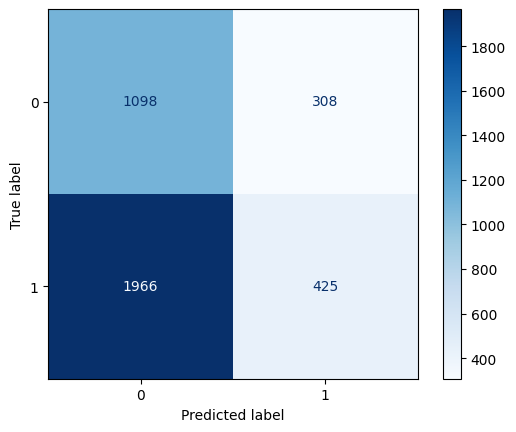

In [8]:
# Retrieve the maximum and minimum valence scores

max_scores = df[score_cols].max(axis=1)
min_scores = df[score_cols].min(axis=1)

# Identify strong splits within a sentence

df['pred_sarcasm_v2'] = (max_scores > 0.05) & (min_scores < -0.05)
df['pred_sarcasm_v2'] = np.where(df['pred_sarcasm_v2'], 'Sarcastic', 'Non-Sarcastic')

# Performance evaluation

print(classification_report(df['label'], df['pred_sarcasm_v2']))
cm = confusion_matrix(df['label'], df['pred_sarcasm_v2'])
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')

The performance of our second rule-based approach is still far from satisfactory. The accuracy is identical to that of the first approach, 0.40. The only difference with respect to the previous model is a small increase in the recall for the "Sarcastic" class, at the expense of a 0.03 decrease in the recall of the "Non-Sarcastic" class. This change can also be identified by comparing the confussion matrices. For the second approach, more sentences have been predicted as "Sarcastic", however, and as we just presented, the gains achieved do not offset the sacrifices made by the model in terms of performance.

In order to further ascertain this model's performance, we have computed the accuracy across different valence thresholds to flag strong positive/negative in splits. 

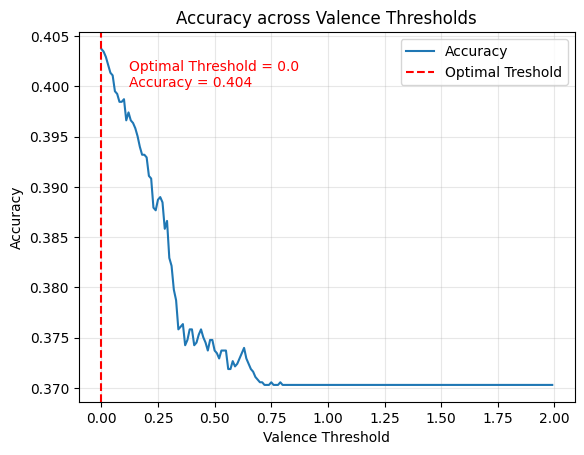

In [9]:
accuracy = []

# Generate threshold space
threshold_list = np.arange(0,2,0.01)

for threshold in threshold_list:
    df['pred_sarcasm_v2'] = (max_scores > threshold) & (min_scores < -threshold)
    df['pred_sarcasm_v2'] = np.where(df['pred_sarcasm_v2'], 'Sarcastic', 'Non-Sarcastic')

    # Performance evaluation
    accuracy.append(accuracy_score(df['label'], df['pred_sarcasm_v2']))

# Plotting

plt.plot(threshold_list, accuracy, label='Accuracy')
plt.title('Accuracy across Valence Thresholds')
plt.xlabel('Valence Threshold')
plt.ylabel('Accuracy')

optimal_threshold = threshold_list[[acc ==max(accuracy) for acc in accuracy].index(True)]

plt.axvline(x=optimal_threshold, color='red', linestyle='--', label='Optimal Treshold')
plt.annotate(f'Optimal Threshold = {round(optimal_threshold,2)}\nAccuracy = {round(max(accuracy),3)}', (optimal_threshold+0.12,0.4), color='red')

plt.grid(alpha=0.3)
plt.legend()
plt.show()

As we display in the plot above, the best performance is achieved by reducing the threshold to 0 and flagging any sentence with a slightly positive and a slightly negative split as "Sarcastic". Note how accuracy does not change dramatically across the different values of valence thresholds.

#### APPROACH 3. Look at the strongest splits within a window

For our third approach, instead of looking for the valence in the split immediate after or looking at the strongest splits within each sentence, we now will look at the strongest splits within a window. The process is as follows: for each sentence, several overlapping windows are generated, and valence is computed using VADER once again. Finally, the maximum and minimum scores, which correspond to those of the most positive and the most negative windows, are returned. A threshold logic identical to that of the previous approach is then applied.

               precision    recall  f1-score   support

Non-Sarcastic       0.36      0.47      0.41      1406
    Sarcastic       0.62      0.52      0.56      2391

     accuracy                           0.50      3797
    macro avg       0.49      0.49      0.49      3797
 weighted avg       0.53      0.50      0.51      3797



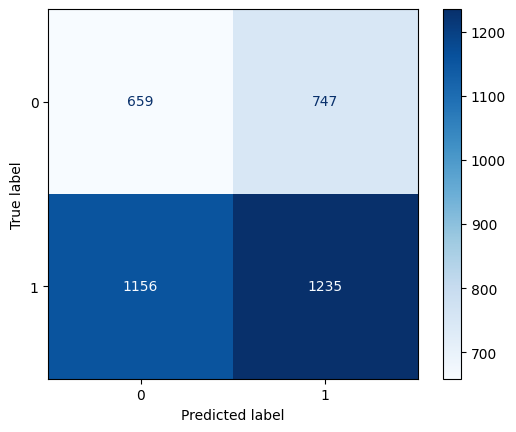

In [10]:
# We define a function that returns the minimum and
# maximum valence scores within a sentence for the 
# specified window size  

def get_window_extremes(text, window_size=2):

    # Handle missing or empty text

    if pd.isna(text) or not str(text).strip():
        return 0.0, 0.0
        
    words = str(text).split()
    
    # If the sentence is shorter than the window, 
    # just score the whole sentence

    if len(words) <= window_size:
        score = analyzer.polarity_scores(text)['compound']
        return score, score
        
    # Generate the overlapping windows

    windows = [' '.join(words[i:i+window_size]) for i in range(len(words) - window_size + 1)]
    
    # Calculate the VADER compound score for each window
    scores = [analyzer.polarity_scores(w)['compound'] for w in windows]
    
    return max(scores), min(scores)

df[['max_score', 'min_score']] = df['Sentence'].apply(
    lambda x: pd.Series(get_window_extremes(x, window_size=4)))

df['pred_sarcasm_v3'] = (df['max_score'] > 0.05) & (df['min_score'] < -0.05)
df['pred_sarcasm_v3'] = np.where(df['pred_sarcasm_v3'], 'Sarcastic', 'Non-Sarcastic')

# Performance evaluation

print(classification_report(df['label'], df['pred_sarcasm_v3']))
cm = confusion_matrix(df['label'], df['pred_sarcasm_v3'])
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')

Although the third approach marks an improvement over the previous ones, with an increase in accuracy of 0.09 points, the model is now as good as random if we had a balanced dataset. On the one hand, if we compare the results to those of the second approach, we can see how the recall for the "Non-Sarcastic" class has decreased notably, dropping to 0.47 from 0.78. On the other hand, all the metrics for the "Sarcastic" class have improved, with a precision of 0.62 (previously, 0.58), a recall of 0.52 (0.18), and an F-1 score of 0.56 (0.27). On the same note, and looking at the confussion matrix, we can see how an improvement in the true positives can be observed, at the expense of a spike in false positives.

In order to further ascertain this model's performance, and similarly to what we did for the previous approach, we have computed the accuracy across different window sizes. 

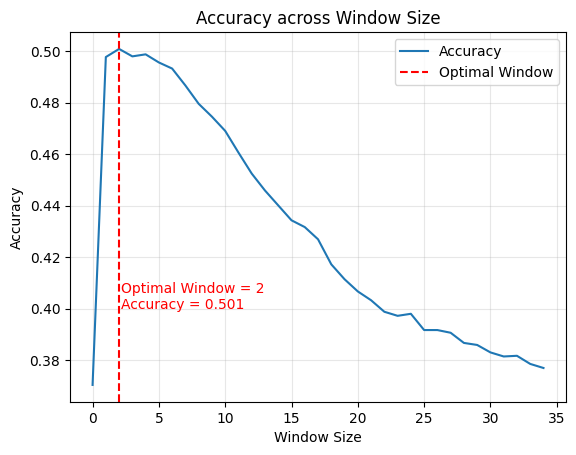

In [11]:
accuracy = []

# Generate window space
window_list = np.arange(0,35,1)

for window in window_list:
    df[['max_score', 'min_score']] = df['Sentence'].apply(
        lambda x: pd.Series(get_window_extremes(x, window_size=window)))

    df['pred_sarcasm_v3'] = (df['max_score'] > 0.05) & (df['min_score'] < -0.05)
    df['pred_sarcasm_v3'] = np.where(df['pred_sarcasm_v3'], 'Sarcastic', 'Non-Sarcastic')

    # Performance evaluation
    accuracy.append(accuracy_score(df['label'], df['pred_sarcasm_v3']))

# Plotting

plt.plot(window_list, accuracy, label='Accuracy')
plt.title('Accuracy across Window Size')
plt.xlabel('Window Size')
plt.ylabel('Accuracy')

optimal_window = window_list[[acc == max(accuracy) for acc in accuracy].index(True)]

plt.axvline(x=optimal_window, color='red', linestyle='--', label='Optimal Window')
plt.annotate(f'Optimal Window = {round(optimal_window,2)}\nAccuracy = {round(max(accuracy),3)}', (optimal_window+0.12,0.4), color='red')

plt.grid(alpha=0.3)
plt.legend()
plt.show()

As can be observed in the plot above, accuracy is stable around 50% for window size 2–4, with a smooth but significant drop in accuracy as the window size is increased. This can be explained by the fact that the wider the window, the less extreme the peaks and valleys become, meaning our rule is triggered less often.

#### APPROACH 4. Combining Approaches 2 and 3

For our final rule-based approach, we combine the techniques used in approaches 2 and 3 to get the best performing model. Specifically, we compute the sentiment intensity for both models and we combine them by adding them up. Finally, a threshold is used to flagged the "Sarcastic" sentences. 

               precision    recall  f1-score   support

Non-Sarcastic       0.36      0.30      0.33      1406
    Sarcastic       0.63      0.68      0.65      2391

     accuracy                           0.54      3797
    macro avg       0.49      0.49      0.49      3797
 weighted avg       0.53      0.54      0.53      3797



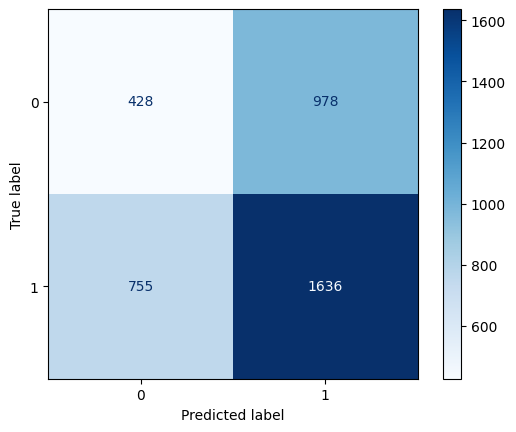

In [ ]:
# Compute intensity for model 2
df['v2_intensity'] = max_scores - min_scores 

# Compute intensity for model 3
df['v3_intensity'] = df['max_score'] - df['min_score']

# Aggregation

df['master_sarcasm_score'] = df['v2_intensity'] + df['v3_intensity']
threshold = 0.4
df['pred_blended'] = np.where(df['master_sarcasm_score'] > threshold, 'Sarcastic', 'Non-Sarcastic')

# Performance evaluation
print(classification_report(df['label'], df['pred_blended']))

cm_blended = confusion_matrix(df['label'], df['pred_blended'])
ConfusionMatrixDisplay(confusion_matrix=cm_blended).plot(cmap='Blues')

The accuracy of this final model has improved over all the previous approaches, but as the confussion matrix above shows, this cannot be attributed to the model learning, but rather, to leveraging the class imbalance and shifting the majority of the predictions to the "Sarcastic" class, which happens to be the dominant class. Therefore, for the "Non-Sarcastic" class, the recall and the F-1 score have fallen, whereas the precision has remained unchanged. For the "Sarcastic" class, and as we just hinted at, a significant increase in recall has been achieved, which, in turn, has also improved the F-1 score.

Once again, we introduce an optimization logic by comparing the accuracy across different thresholds.

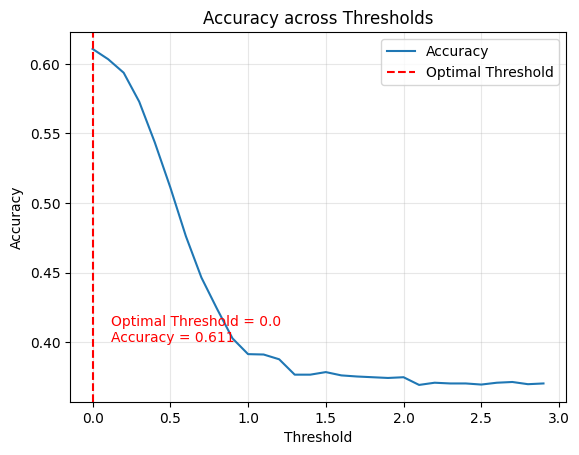

In [13]:
accuracy = []

# Generate threshold space
threshold_list = np.arange(0,3,0.1)

for threshold in threshold_list:
    df['pred_blended'] = np.where(df['master_sarcasm_score'] > threshold, 'Sarcastic', 'Non-Sarcastic')

    # Performance evaluation
    accuracy.append(accuracy_score(df['label'], df['pred_blended']))

# Plotting

plt.plot(threshold_list, accuracy, label='Accuracy')
plt.title('Accuracy across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')

optimal_threshold = threshold_list[[acc ==max(accuracy) for acc in accuracy].index(True)]

plt.axvline(x=optimal_threshold, color='red', linestyle='--', label='Optimal Threshold')
plt.annotate(f'Optimal Threshold = {round(optimal_threshold,2)}\nAccuracy = {round(max(accuracy),3)}', (optimal_threshold+0.12,0.4), color='red')

plt.grid(alpha=0.3)
plt.legend()
plt.show()

As we expected, the best performing model, which corresponds to using a 0 threshold and which yields an accuracy of 0.61, simply flags every sentence as "Sarcastic".

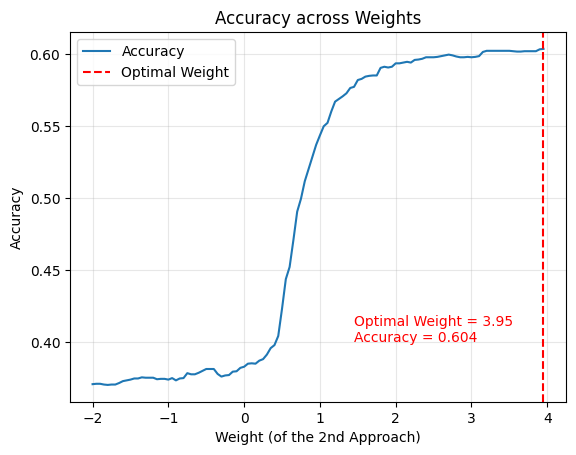

In [14]:
accuracy = []

# Generate weight space

weight_list = np.arange(-2,4,0.05)

for weight in weight_list:
    df['master_sarcasm_score'] = (weight*df['v2_intensity']) + (df['v3_intensity'])
    df['pred_blended'] = np.where(df['master_sarcasm_score'] > 0.4, 'Sarcastic', 'Non-Sarcastic')

    # Performance evaluation
    accuracy.append(accuracy_score(df['label'], df['pred_blended']))

# Plotting

plt.plot(weight_list, accuracy, label='Accuracy')
plt.title('Accuracy across Weights')
plt.xlabel('Weight (of the 2nd Approach)')
plt.ylabel('Accuracy')

optimal_weight = weight_list[[acc ==max(accuracy) for acc in accuracy].index(True)]

plt.axvline(x=optimal_weight, color='red', linestyle='--', label='Optimal Weight')
plt.annotate(f'Optimal Weight = {round(optimal_weight,2)}\nAccuracy = {round(max(accuracy),3)}', (optimal_weight-2.5,0.4), color='red')

plt.grid(alpha=0.3)
plt.legend()
plt.show()

Furthermore, we also perform a weight optimization for the mixing weights in the sum between the results from the second and third approaches. We find that, by upweighting the predictions from the second approach, accuracy is increased as the model simply predicts "Sarastic" for every sentence. Similarly, by upweighting the predictions from the third approach, accuracy is decreased and converges to the share of "Non-Sarcastic" sentences, as we are now predicting "Non-Sarcastic" for every sentence. 

#### PERFORMANCE DISCUSSION AND HUMAN-LEVEL PERFORMANCE COMPARISON

As we have presented, we have thoroughly evaluated the classification task at hand with four different rule-based approaches. In some cases, for approaches 1 and 2, their accuracy was lower than if we simply guessed randomly, even without taking into account the class imbalance. Moreover, none of the approaches have proven to perform better than simply guessing the majority "Sarcastic" class, which yields an accuracy of $\sim 60\%$.

To properly assess the poor performance of the models, we should take into account the complexity of our classification problem. Sarcasm in language is largely dependent on the context, the tone, and many other nuances, which a simple, rule-based approach cannot easily capture. Additionally, if we take the Inter-Annotator agreement as a proxy for the human-level performance for our dataset (63.92%), we can further illustrate how even for humans, the classification of sarcastic sentences is not an easy task. Notice, however, that the accuracy of the models presented cannot be directly compared to the Inter-Annotator agreement, provided that the former are computed for the subsample of our data where the annotators agreed.

Human-level performance in the literature is largely dependent on the dataset, as cleaner, easier datasets can reach a performance of 85–90%, but more noisy and complex ones struggle to achieve this level of human performance.